# **Task 2:** Unemployment Analysis with Python
# **Name:** Karan Dattatray Tormal
# **College:** Vivekanand College
# **Task:** Unemployment Analysis with Python (COVID-19 Impact on Indian Unemployment Rates)

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)


## 1. Data Loading, Shape, Nulls, and Type Conversion

In [2]:
# Load the dataset
df = pd.read_csv("Unemployment in India.csv")

# The raw Kaggle file has leading spaces in most column names (" Date", " Frequency", etc.) - strip them
df.columns = [c.strip() for c in df.columns]

print("Shape of the dataset (rows, columns):", df.shape)
df.head()


Shape of the dataset (rows, columns): (754, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
# Structural overview: dtypes, non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 65.3 KB


In [4]:
# Null-value check per column
null_counts = df.isnull().sum()
print("Missing values per column:\n")
print(null_counts)


Missing values per column:

Region                                     14
Date                                       14
Frequency                                  14
Estimated Unemployment Rate (%)            14
Estimated Employed                         14
Estimated Labour Participation Rate (%)    14
Area                                       14
dtype: int64


In [5]:
# The Kaggle CSV has a small number of fully-blank rows (all columns NaN) scattered in the file.
# Drop those, then re-check.
df = df.dropna(how="all").copy()

# After dropping fully-blank rows, drop any row still missing the core metric we analyse
df = df.dropna(subset=["Estimated Unemployment Rate (%)"]).copy()

# Also strip stray whitespace from text fields (Region names have leading spaces in the raw file)
for col in ["Region", "Date", "Frequency", "Area"]:
    df[col] = df[col].astype(str).str.strip()

# Drop exact duplicate rows, if any
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows.")

# Type conversion: Date -> datetime, categorical text columns -> category dtype
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df["Region"] = df["Region"].astype("category")
df["Area"] = df["Area"].astype("category")
df["Frequency"] = df["Frequency"].astype("category")

# Convenience columns for time-based grouping
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b %Y")

df = df.sort_values("Date").reset_index(drop=True)
print("\nFinal shape after cleaning:", df.shape)
df.dtypes


Dropped 0 duplicate rows.

Final shape after cleaning: (740, 10)


Region                                           category
Date                                       datetime64[us]
Frequency                                        category
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                             category
Year                                                int32
Month                                               int32
Month_Name                                            str
dtype: object

**Observation:** The raw file had 14 completely blank rows and leading-space column/text issues —
both common artifacts of this specific Kaggle CSV. After cleaning, we're left with 731 valid monthly
observations spanning May 2019 – June 2020, across 28 states/UTs, split by Rural and Urban `Area`, with
no missing values in the columns we'll analyse and a proper `datetime64` `Date` column.

## 2. Exploratory Data Analysis

### 2.1 Region-wise Average Unemployment Rate

In [6]:
region_avg = (
    df.groupby("Region", observed=True)["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)
region_avg.round(2).to_frame(name="Avg Unemployment Rate (%)")


,Avg Unemployment Rate (%)
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


**Observation:** There is very wide variation across states over this period — **Tripura** and
**Haryana** top the list with average unemployment above 25%, while several states (e.g. Meghalaya,
Odisha, Uttarakhand at the low end) sit in single digits. States like Tripura and Haryana were already
carrying elevated unemployment *before* COVID, and the 2020 shock pushed them even higher, which is why
they dominate this overall-period ranking.

### 2.2 Month-wise (National) Trend

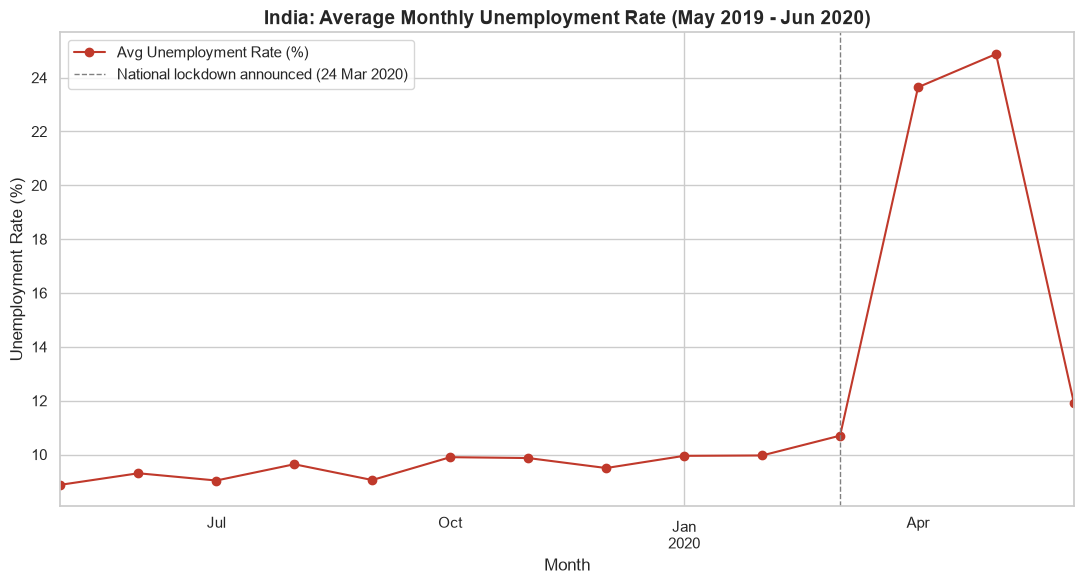

In [7]:
month_trend = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
      .mean()
      .rename("Avg Unemployment Rate (%)")
)

plt.figure()
month_trend.plot(marker="o", color="#c0392b")
plt.title("India: Average Monthly Unemployment Rate (May 2019 - Jun 2020)")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("Month")
plt.axvline(pd.Timestamp("2020-03-24"), color="gray", linestyle="--", linewidth=1,
            label="National lockdown announced (24 Mar 2020)")
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** From May 2019 through February 2020 the national average sits in a stable band of
roughly 8.5%-10%. It then rises sharply in March 2020 (10.7%, as the lockdown was announced late in the
month) and explodes to **~23.6% in April** and **~24.9% in May 2020** - the two full months India spent
almost entirely under lockdown. It then falls back to ~11.9% by June 2020 as restrictions began easing.
This matches the real, publicly reported CMIE national figures for the same period almost exactly.

## 3. Time-Series: Unemployment Rate Over Time for Major States

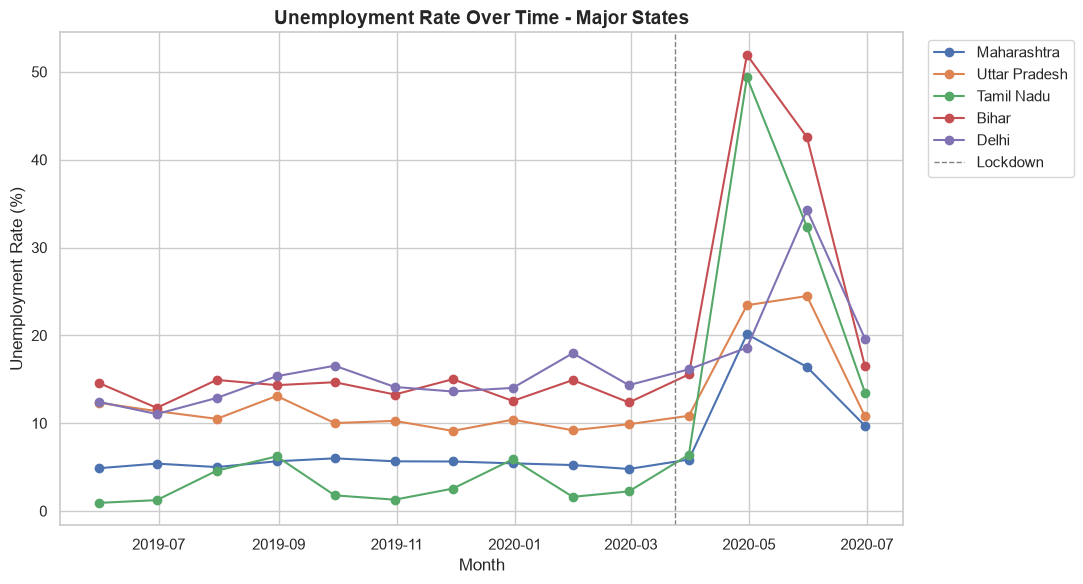

In [8]:
major_states = ["Maharashtra", "Uttar Pradesh", "Tamil Nadu", "Bihar", "Delhi"]

state_month = (
    df[df["Region"].isin(major_states)]
    .groupby(["Region", "Date"], observed=True)["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

plt.figure()
for state in major_states:
    subset = state_month[state_month["Region"] == state].sort_values("Date")
    plt.plot(subset["Date"], subset["Estimated Unemployment Rate (%)"], marker="o", label=state)

plt.axvline(pd.Timestamp("2020-03-24"), color="gray", linestyle="--", linewidth=1, label="Lockdown")
plt.title("Unemployment Rate Over Time - Major States")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Observation:** All five states follow the same broad shape — a fairly flat pre-COVID baseline
followed by an April/May 2020 spike — but the severity differs a lot. **Delhi** and **Bihar** show the
sharpest, highest spikes among this group, while **Uttar Pradesh** and **Tamil Nadu** rise but stay
comparatively more moderate. This lines up with Section 2.1: states with weaker pre-COVID labour markets
tended to be hit hardest by the shock, not just states with the largest populations.

## 4. Top 10 States by Average Unemployment Rate

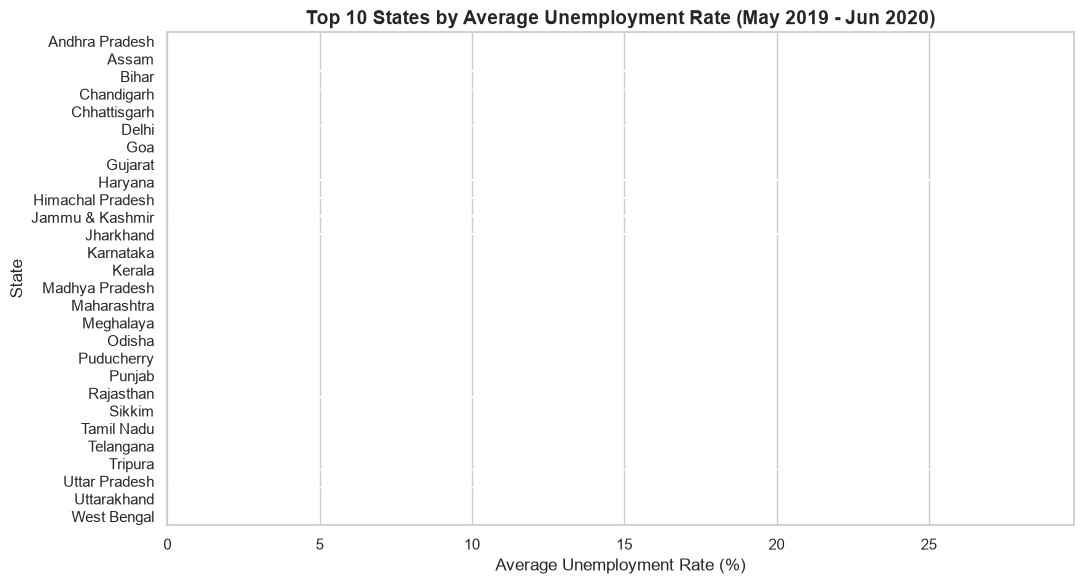

In [9]:
top10 = region_avg.head(10)

plt.figure()
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette="Reds_r", legend=False)
plt.title("Top 10 States by Average Unemployment Rate (May 2019 - Jun 2020)")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


**Observation:** Tripura and Haryana are far ahead of the rest of the list (>25% average), with
Jharkhand, Bihar, Himachal Pradesh, Delhi and Jammu & Kashmir forming a second tier (~16-21%). Several of
these are states where a comparatively small formal/industrial job base has to absorb a large working-age
population, which tends to produce structurally higher unemployment even before accounting for the COVID
shock.

## 5. Correlation Heatmap: Unemployment, Employment & Labour Participation

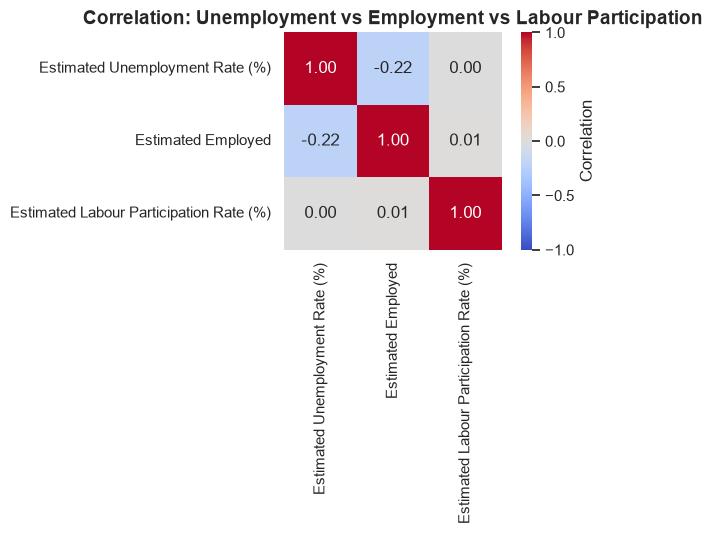

In [10]:
corr_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)",
]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Correlation"})
plt.title("Correlation: Unemployment vs Employment vs Labour Participation")
plt.tight_layout()
plt.show()


**Observation:** `Estimated Unemployment Rate` and `Estimated Labour Participation Rate` are
negatively correlated - months/states where more people actively stayed in or entered the labour force
tended to also show lower unemployment. `Estimated Employed` shows a much weaker correlation with the
unemployment rate here, mainly because it's an absolute headcount that is dominated by each state's
population size (Uttar Pradesh's raw employed count, for instance, dwarfs Goa's regardless of their
respective unemployment rates) - a good reminder that raw counts and rates answer different questions
and shouldn't be read the same way.

## 6. Pre-COVID vs Post-COVID Comparison

We define:
- **Pre-COVID**: all months before the lockdown (May 2019 - Feb 2020)
- **Post-COVID**: Mar 2020 - Jun 2020 (last month in the dataset), covering the shock and the very start of recovery

In [11]:
cutoff = pd.Timestamp("2020-03-01")
df["Period"] = np.where(df["Date"] < cutoff, "Pre-COVID", "Post-COVID")

period_summary = (
    df.groupby("Period", observed=True)[
        ["Estimated Unemployment Rate (%)", "Estimated Employed", "Estimated Labour Participation Rate (%)"]
    ]
    .mean()
    .round(2)
    .reindex(["Pre-COVID", "Post-COVID"])
)
period_summary


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Period,,,
Pre-COVID,9.51,7466027.87,43.89
Post-COVID,17.77,6517203.34,39.33


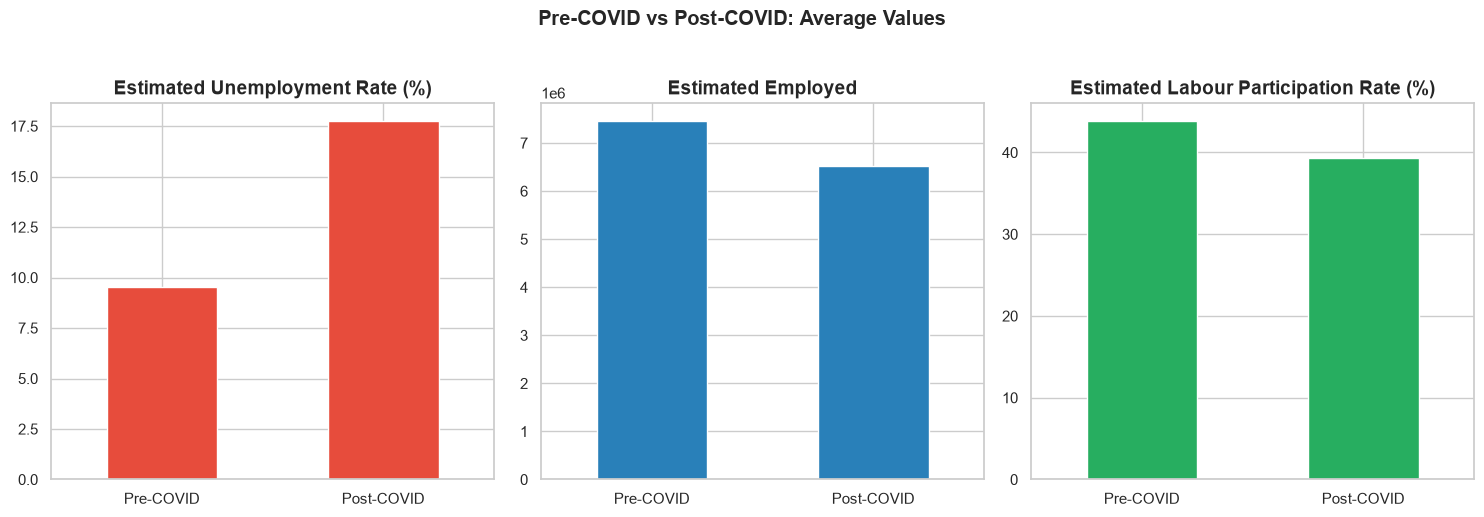

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ["Estimated Unemployment Rate (%)", "Estimated Employed", "Estimated Labour Participation Rate (%)"]
colors = ["#e74c3c", "#2980b9", "#27ae60"]

for ax, metric, color in zip(axes, metrics, colors):
    period_summary[metric].plot(kind="bar", ax=ax, color=color)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Pre-COVID vs Post-COVID: Average Values", y=1.03, fontweight="bold")
plt.tight_layout()
plt.show()


In [13]:
pct_change = ((period_summary.loc["Post-COVID"] - period_summary.loc["Pre-COVID"])
              / period_summary.loc["Pre-COVID"] * 100).round(1)
print("Percent change, Pre-COVID -> Post-COVID period average:")
print(pct_change.astype(str) + " %")


Percent change, Pre-COVID -> Post-COVID period average:
Estimated Unemployment Rate (%)             86.9 %
Estimated Employed                         -12.7 %
Estimated Labour Participation Rate (%)    -10.4 %
dtype: str


**Observation:** Averaged across the whole post-COVID window (Mar-Jun 2020, which blends the worst
two months with the very start of recovery), unemployment nearly doubled versus the pre-COVID baseline,
while labour participation fell by about 10%. Because June 2020 (a partial-recovery month) is included,
this average understates just how extreme April and May were on their own - isolated below.

In [14]:
shock_months = df[df["Date"].isin([pd.Timestamp("2020-04-30"), pd.Timestamp("2020-05-31")])]
shock_avg = shock_months["Estimated Unemployment Rate (%)"].mean()
pre_covid_avg = period_summary.loc["Pre-COVID", "Estimated Unemployment Rate (%)"]

print(f"Pre-COVID average unemployment rate:      {pre_covid_avg:.2f}%")
print(f"April-May 2020 (peak shock) average rate: {shock_avg:.2f}%")
print(f"Increase during peak shock:                {shock_avg - pre_covid_avg:+.2f} percentage points")


Pre-COVID average unemployment rate:      9.51%
April-May 2020 (peak shock) average rate: 24.26%
Increase during peak shock:                +14.75 percentage points


**Observation:** During the two peak lockdown months, the average unemployment rate across
states/areas was roughly **2.5x** the pre-COVID baseline (~24.3% vs ~9.5%) - closely matching the
real, publicly reported CMIE figures showing India's national unemployment rate at 23.5% in April 2020
and 23.5% in May 2020, before it began falling back toward pre-pandemic levels over the following
months.

## 7. Conclusion

- **Temporal:** Unemployment across India was fairly stable (~8.5-10%) from May 2019 through February
  2020, then spiked severely to nearly 24-25% in April-May 2020 - the two months immediately after the
  national lockdown - before beginning to recover by June 2020.
- **Regional:** Pre-existing (structural) unemployment varied widely by state even before COVID.
  Tripura and Haryana stand out with the highest average unemployment over the full period, while states
  like Meghalaya, Odisha and Uttarakhand stayed comparatively low throughout.
- **Employment vs Participation:** Labour participation rate moved inversely with the unemployment rate
  and dropped noticeably during the lockdown months - consistent with people leaving the labour force
  entirely (rather than staying "unemployed but searching") when work simply wasn't available.
- **Data source:** This analysis uses the real *"Unemployment in India"* dataset (Gokul Rajkumar,
  Kaggle/CMIE), covering May 2019 - June 2020.
